In [1]:
import polars as pl
import pandas as pd

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/user/dapractice/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/user/dapractice/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/dapractice/.venv/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/user/dapractice/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/user/dapractice/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in sh

In [2]:
listing_file_path: str = "Listings.csv"
listing_dict_file_path: str = "lesson/16th/Listings_data_dictionary.csv"
review_file_path: str = "lesson/16th/Reviews.csv"
review_dict_file_path: str = "lesson/16th/Reviews_data_dictionary.csv"

## Reading data with data is not correct utf8 -> solution: using encoding = "utf8-lossy"

In [3]:
df_listing: pl.DataFrame = (
    pl.read_csv(
        listing_file_path,
        has_header=True,
        infer_schema_length=0,
        truncate_ragged_lines=True,
        encoding="utf8-lossy"
    )
)
df_listing.head()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""281420""","""Beautiful Flat in le Village M…","""1466919""","""2011-12-03""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Buttes-Montmartre""",null,"""Paris""","""48.88668""","""2.33343""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""Kitchen"", ""Washer…","""53""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""3705183""","""39 mÂ² Paris (Sacre CÅ“ur)""","""10328771""","""2013-11-29""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Buttes-Montmartre""",null,"""Paris""","""48.88617""","""2.34515""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Shampoo"", ""Heating"", ""Kitche…","""120""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4082273""","""Lovely apartment with Terrace,…","""19252768""","""2014-07-31""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Elysee""",null,"""Paris""","""48.88112""","""2.31712""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""89""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4797344""","""Cosy studio (close to Eiffel t…","""10668311""","""2013-12-17""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Vaugirard""",null,"""Paris""","""48.84571""","""2.30584""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""58""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4823489""","""Close to Eiffel Tower - Beauti…","""24837558""","""2014-12-14""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Passy""",null,"""Paris""","""48.855""","""2.26979""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""60""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""


In [4]:
# Claude solution
import ftfy

df_listing = df_listing.with_columns(
    pl.col("name").map_elements(
        lambda x: ftfy.fix_text(x) if x is not None else x,
        return_dtype=pl.String
    )
)
df_listing.head()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""281420""","""Beautiful Flat in le Village M…","""1466919""","""2011-12-03""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Buttes-Montmartre""",null,"""Paris""","""48.88668""","""2.33343""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""Kitchen"", ""Washer…","""53""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""3705183""","""39 m² Paris (Sacre Cœur)""","""10328771""","""2013-11-29""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Buttes-Montmartre""",null,"""Paris""","""48.88617""","""2.34515""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Shampoo"", ""Heating"", ""Kitche…","""120""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4082273""","""Lovely apartment with Terrace,…","""19252768""","""2014-07-31""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Elysee""",null,"""Paris""","""48.88112""","""2.31712""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""89""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4797344""","""Cosy studio (close to Eiffel t…","""10668311""","""2013-12-17""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Vaugirard""",null,"""Paris""","""48.84571""","""2.30584""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""58""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4823489""","""Close to Eiffel Tower - Beauti…","""24837558""","""2014-12-14""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Passy""",null,"""Paris""","""48.855""","""2.26979""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""60""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""


In [5]:
# Other way: encoding="iso-8859-1" then using ftfy
"""
df_listing: pl.DataFrame = (
    pl.scan_csv(
        listing_file_path,
        has_header=True,
        infer_schema_length=0,
        truncate_ragged_lines=True,
        encoding="iso-8859-1"
    ).collect()
)

df_listing = df_listing.with_columns(
    pl.col("name").map_elements(
        lambda x: ftfy.fix_text(x) if x is not None else x,
        return_dtype=pl.String
    )
)
df_listing.head()
"""

'\ndf_listing: pl.DataFrame = (\n    pl.scan_csv(\n        listing_file_path,\n        has_header=True,\n        infer_schema_length=0,\n        truncate_ragged_lines=True,\n        encoding="iso-8859-1"\n    ).collect()\n)\n\ndf_listing = df_listing.with_columns(\n    pl.col("name").map_elements(\n        lambda x: ftfy.fix_text(x) if x is not None else x,\n        return_dtype=pl.String\n    )\n)\ndf_listing.head()\n'

In [6]:
# df_listing["host_location"].unique().to_list()

## Initial Data Analyst (IDA)

### Get data type per column

In [7]:
listing_schema = pl.scan_csv(listing_file_path, encoding="utf8-lossy", has_header=True).collect_schema()
listing_schema = pl.DataFrame(listing_schema).to_dicts()[0]
listing_schema

{'listing_id': Int64,
 'name': String,
 'host_id': Int64,
 'host_since': String,
 'host_location': String,
 'host_response_time': String,
 'host_response_rate': String,
 'host_acceptance_rate': String,
 'host_is_superhost': String,
 'host_total_listings_count': Int64,
 'host_has_profile_pic': String,
 'host_identity_verified': String,
 'neighbourhood': String,
 'district': String,
 'city': String,
 'latitude': Float64,
 'longitude': Float64,
 'property_type': String,
 'room_type': String,
 'accommodates': Int64,
 'bedrooms': Int64,
 'amenities': String,
 'price': Int64,
 'minimum_nights': Int64,
 'maximum_nights': Int64,
 'review_scores_rating': Int64,
 'review_scores_accuracy': Int64,
 'review_scores_cleanliness': Int64,
 'review_scores_checkin': Int64,
 'review_scores_communication': Int64,
 'review_scores_location': Int64,
 'review_scores_value': Int64,
 'instant_bookable': String}

In [8]:
numeric_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, (pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.Float16, pl.Float32, pl.Float64))]
numeric_col_list

['listing_id',
 'host_id',
 'host_total_listings_count',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'price',
 'minimum_nights',
 'maximum_nights',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value']

In [9]:
string_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, (pl.Utf8))]
string_col_list

['name',
 'host_since',
 'host_location',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'district',
 'city',
 'property_type',
 'room_type',
 'amenities',
 'instant_bookable']

In [10]:
object_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, pl.Object)]
object_col_list

[]

In [11]:
struct_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, pl.Struct)]
struct_col_list

[]

### Check shape

In [12]:
df_listing.shape

(279712, 33)

### Count null value

In [13]:
df_null_count = df_listing.null_count().transpose(include_header=True).rename({"column_0": "null_count"})
df_null_count = df_null_count.with_columns(
    (pl.col("null_count") / df_listing.shape[0] * 100).round(2).alias("null_percentage(%)")
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_null_count)



shape: (33, 3)
┌─────────────────────────────┬────────────┬────────────────────┐
│ column                      ┆ null_count ┆ null_percentage(%) │
│ ---                         ┆ ---        ┆ ---                │
│ str                         ┆ u32        ┆ f64                │
╞═════════════════════════════╪════════════╪════════════════════╡
│ listing_id                  ┆ 0          ┆ 0.0                │
│ name                        ┆ 171        ┆ 0.06               │
│ host_id                     ┆ 0          ┆ 0.0                │
│ host_since                  ┆ 165        ┆ 0.06               │
│ host_location               ┆ 832        ┆ 0.3                │
│ host_response_time          ┆ 128782     ┆ 46.04              │
│ host_response_rate          ┆ 128782     ┆ 46.04              │
│ host_acceptance_rate        ┆ 113087     ┆ 40.43              │
│ host_is_superhost           ┆ 165        ┆ 0.06               │
│ host_total_listings_count   ┆ 165        ┆ 0.06            

In [14]:
# Count not null
df_listing.count()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
279712,279541,279712,279547,278880,150930,150930,166625,279547,279547,279547,279547,279712,37012,279712,279712,279712,279712,279712,279712,250277,279712,279712,279712,279712,188307,187999,188047,187941,188025,187937,187927,279712


In [15]:
# Not null percentage
df_listing.count() / df_listing.shape[0] * 100

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
100.0,99.938866,100.0,99.941011,99.702551,53.959072,53.959072,59.570201,99.941011,99.941011,99.941011,99.941011,100.0,13.232182,100.0,100.0,100.0,100.0,100.0,100.0,89.476676,100.0,100.0,100.0,100.0,67.321745,67.211632,67.228792,67.190896,67.220927,67.189466,67.185891,100.0


In [16]:
df_listing = df_listing.with_columns([
    pl.col(column).cast(pl.Float64) for column in numeric_col_list
])
df_listing.select(numeric_col_list).describe()

statistic,listing_id,host_id,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",279712.0,279712.0,279547.0,279712.0,279712.0,279712.0,250277.0,279712.0,279712.0,279712.0,188307.0,187999.0,188047.0,187941.0,188025.0,187937.0,187927.0
"""null_count""",0.0,0.0,165.0,0.0,0.0,0.0,29435.0,0.0,0.0,0.0,91405.0,91713.0,91665.0,91771.0,91687.0,91775.0,91785.0
"""mean""",2.6382e7,1.0817e8,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,27558.596667,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
"""std""",1.4426e7,1.1086e8,284.041143,32.560343,73.081309,2.133379,1.15308,3441.826611,31.518946,7.2829e6,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
"""min""",2577.0,1822.0,0.0,-34.2644,-99.33963,0.0,1.0,0.0,1.0,1.0,20.0,2.0,2.0,2.0,2.0,2.0,2.0
"""25%""",1.3844634e7,1.7206558e7,1.0,-22.96439,-43.19804,2.0,1.0,75.0,1.0,45.0,91.0,9.0,9.0,10.0,10.0,9.0,9.0
"""50%""",2.7671096e7,5.8271557e7,1.0,40.71079,2.38278,2.0,1.0,150.0,2.0,1125.0,96.0,10.0,10.0,10.0,10.0,10.0,10.0
"""75%""",3.9784817e7,1.83285283e8,4.0,41.90861,28.98673,4.0,2.0,474.0,5.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0
"""max""",4.834353e7,3.90187445e8,7235.0,48.90491,151.33981,16.0,50.0,625216.0,9999.0,2.1475e9,100.0,10.0,10.0,10.0,10.0,10.0,10.0


In [17]:
df_listing.with_row_index().filter(
    pl.col("maximum_nights") == pl.col("maximum_nights").max()
)

index,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
u32,f64,str,f64,str,str,str,str,str,str,f64,str,str,str,str,str,f64,f64,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
228967,4.234075e6,"""Residenza dei Pontefici, San P…",2.1971342e7,"""2014-09-30""","""Rome, Lazio, Italy""",null,null,"""1""","""f""",2.0,"""t""","""t""","""XIII Aurelia""",null,"""Rome""",41.89737,12.44891,"""Entire apartment""","""Entire place""",9.0,2.0,"""[""Pack \u2019n Play/travel cri…",100.0,2.0,2.1475e9,93.0,10.0,9.0,10.0,10.0,10.0,9.0,"""t"""
251162,6.357527e6,"""Great UWS Studio Apartment""",1.8762837e7,"""2014-07-23""","""New York, New York, United Sta…",null,null,null,"""f""",1.0,"""t""","""t""","""Upper West Side""","""Manhattan""","""New York""",40.79159,-73.97809,"""Entire apartment""","""Entire place""",1.0,null,"""[""TV"", ""Wifi"", ""Cable TV"", ""He…",130.0,30.0,2.1475e9,73.0,7.0,7.0,7.0,7.0,9.0,7.0,"""f"""
259338,744242.0,"""#Old City#Authentic Duplex #Te…",4.334558e6,"""2012-12-05""","""Istanbul, Turkey""",null,null,"""1""","""f""",1.0,"""t""","""t""","""Fatih""",null,"""Istanbul""",41.01094,28.95067,"""Entire apartment""","""Entire place""",7.0,2.0,"""[""Carbon monoxide alarm"", ""Cof…",289.0,2.0,2.1475e9,92.0,9.0,9.0,10.0,10.0,10.0,9.0,"""f"""


In [18]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(
        df_listing.select(
            pl.col("review_scores_accuracy")
            .value_counts(sort=True)
            )
            .unnest("review_scores_accuracy")
    )

shape: (10, 2)
┌────────────────────────┬────────┐
│ review_scores_accuracy ┆ count  │
│ ---                    ┆ ---    │
│ f64                    ┆ u32    │
╞════════════════════════╪════════╡
│ 10.0                   ┆ 136390 │
│ null                   ┆ 91713  │
│ 9.0                    ┆ 37176  │
│ 8.0                    ┆ 8712   │
│ 6.0                    ┆ 1974   │
│ 7.0                    ┆ 1795   │
│ 2.0                    ┆ 1152   │
│ 4.0                    ┆ 527    │
│ 5.0                    ┆ 240    │
│ 3.0                    ┆ 33     │
└────────────────────────┴────────┘


In [19]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_acceptance_rate").value_counts(sort=True)).unnest("host_acceptance_rate"))

shape: (102, 2)
┌──────────────────────┬────────┐
│ host_acceptance_rate ┆ count  │
│ ---                  ┆ ---    │
│ str                  ┆ u32    │
╞══════════════════════╪════════╡
│ null                 ┆ 113087 │
│ 1                    ┆ 75555  │
│ 0                    ┆ 11431  │
│ 0.99                 ┆ 7227   │
│ 0.5                  ┆ 5445   │
│ 0.98                 ┆ 5085   │
│ 0.97                 ┆ 4523   │
│ 0.67                 ┆ 3702   │
│ 0.94                 ┆ 3642   │
│ 0.96                 ┆ 3287   │
│ 0.75                 ┆ 3009   │
│ 0.93                 ┆ 2532   │
│ 0.95                 ┆ 2419   │
│ 0.92                 ┆ 2333   │
│ 0.8                  ┆ 2301   │
│ 0.88                 ┆ 2063   │
│ 0.83                 ┆ 2019   │
│ 0.9                  ┆ 2002   │
│ 0.33                 ┆ 1931   │
│ 0.89                 ┆ 1810   │
│ 0.91                 ┆ 1806   │
│ 0.86                 ┆ 1728   │
│ 0.71                 ┆ 1330   │
│ 0.82                 ┆ 1138   

In [20]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_response_time").value_counts(sort=True)).unnest("host_response_time"))

shape: (5, 2)
┌────────────────────┬────────┐
│ host_response_time ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ null               ┆ 128782 │
│ within an hour     ┆ 83464  │
│ within a few hours ┆ 28891  │
│ within a day       ┆ 23425  │
│ a few days or more ┆ 15150  │
└────────────────────┴────────┘


In [21]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_response_rate").value_counts(sort=True)).unnest("host_response_rate"))

shape: (92, 2)
┌────────────────────┬────────┐
│ host_response_rate ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ null               ┆ 128782 │
│ 1                  ┆ 99334  │
│ 0                  ┆ 10640  │
│ 0.9                ┆ 4982   │
│ 0.5                ┆ 3639   │
│ 0.8                ┆ 3085   │
│ 0.99               ┆ 2294   │
│ 0.67               ┆ 1901   │
│ 0.98               ┆ 1708   │
│ 0.95               ┆ 1633   │
│ 0.97               ┆ 1471   │
│ 0.75               ┆ 1445   │
│ 0.94               ┆ 1289   │
│ 0.93               ┆ 1263   │
│ 0.96               ┆ 1207   │
│ 0.89               ┆ 1065   │
│ 0.92               ┆ 1015   │
│ 0.88               ┆ 960    │
│ 0.7                ┆ 948    │
│ 0.33               ┆ 947    │
│ 0.83               ┆ 928    │
│ 0.6                ┆ 891    │
│ 0.86               ┆ 658    │
│ 0.2                ┆ 650    │
│ 0.91               ┆ 559    │
│ 0.4                ┆ 54

In [22]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("accommodates").value_counts(sort=True)).unnest("accommodates"))

shape: (17, 2)
┌──────────────┬────────┐
│ accommodates ┆ count  │
│ ---          ┆ ---    │
│ f64          ┆ u32    │
╞══════════════╪════════╡
│ 2.0          ┆ 118332 │
│ 4.0          ┆ 57260  │
│ 3.0          ┆ 27936  │
│ 1.0          ┆ 25813  │
│ 6.0          ┆ 19455  │
│ 5.0          ┆ 13527  │
│ 8.0          ┆ 6514   │
│ 7.0          ┆ 3697   │
│ 10.0         ┆ 2630   │
│ 16.0         ┆ 1162   │
│ 9.0          ┆ 1140   │
│ 12.0         ┆ 1052   │
│ 11.0         ┆ 367    │
│ 14.0         ┆ 331    │
│ 15.0         ┆ 214    │
│ 13.0         ┆ 197    │
│ 0.0          ┆ 85     │
└──────────────┴────────┘


In [23]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("bedrooms").value_counts(sort=True)).unnest("bedrooms"))

shape: (40, 2)
┌──────────┬────────┐
│ bedrooms ┆ count  │
│ ---      ┆ ---    │
│ f64      ┆ u32    │
╞══════════╪════════╡
│ 1.0      ┆ 170163 │
│ 2.0      ┆ 51382  │
│ null     ┆ 29435  │
│ 3.0      ┆ 18525  │
│ 4.0      ┆ 6579   │
│ 5.0      ┆ 2106   │
│ 6.0      ┆ 701    │
│ 7.0      ┆ 246    │
│ 10.0     ┆ 150    │
│ 8.0      ┆ 124    │
│ 9.0      ┆ 79     │
│ 12.0     ┆ 38     │
│ 11.0     ┆ 32     │
│ 50.0     ┆ 22     │
│ 20.0     ┆ 22     │
│ 16.0     ┆ 16     │
│ 14.0     ┆ 15     │
│ 15.0     ┆ 12     │
│ 40.0     ┆ 10     │
│ 13.0     ┆ 7      │
│ 22.0     ┆ 5      │
│ 24.0     ┆ 4      │
│ 30.0     ┆ 4      │
│ 18.0     ┆ 4      │
│ 23.0     ┆ 4      │
│ 17.0     ┆ 3      │
│ 19.0     ┆ 3      │
│ 33.0     ┆ 3      │
│ 35.0     ┆ 2      │
│ 46.0     ┆ 2      │
│ 21.0     ┆ 2      │
│ 31.0     ┆ 2      │
│ 38.0     ┆ 2      │
│ 39.0     ┆ 2      │
│ 42.0     ┆ 1      │
│ 34.0     ┆ 1      │
│ 25.0     ┆ 1      │
│ 26.0     ┆ 1      │
│ 41.0     ┆ 1      │
│ 48.0     ┆ 1   

In [24]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_total_listings_count").value_counts(sort=True)).unnest("host_total_listings_count"))

shape: (207, 2)
┌───────────────────────────┬────────┐
│ host_total_listings_count ┆ count  │
│ ---                       ┆ ---    │
│ f64                       ┆ u32    │
╞═══════════════════════════╪════════╡
│ 1.0                       ┆ 117559 │
│ 2.0                       ┆ 35778  │
│ 0.0                       ┆ 33265  │
│ 3.0                       ┆ 17230  │
│ 4.0                       ┆ 11216  │
│ 5.0                       ┆ 7993   │
│ 6.0                       ┆ 5880   │
│ 7.0                       ┆ 4666   │
│ 8.0                       ┆ 3895   │
│ 9.0                       ┆ 2978   │
│ 10.0                      ┆ 2599   │
│ 11.0                      ┆ 2257   │
│ 13.0                      ┆ 1862   │
│ 12.0                      ┆ 1756   │
│ 15.0                      ┆ 1258   │
│ 14.0                      ┆ 1208   │
│ 16.0                      ┆ 1032   │
│ 18.0                      ┆ 979    │
│ 17.0                      ┆ 912    │
│ 20.0                      ┆ 844    │
│ 19.0   

In [25]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("property_type").value_counts(sort=True)).unnest("property_type"))

shape: (144, 2)
┌─────────────────────────────────┬────────┐
│ property_type                   ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Entire apartment                ┆ 138989 │
│ Private room in apartment       ┆ 47322  │
│ Private room in house           ┆ 13292  │
│ Entire house                    ┆ 13273  │
│ Entire condominium              ┆ 11250  │
│ Room in boutique hotel          ┆ 5771   │
│ Entire loft                     ┆ 4587   │
│ Private room in condominium     ┆ 4462   │
│ Private room in bed and breakf… ┆ 4238   │
│ Entire serviced apartment       ┆ 3973   │
│ Room in hotel                   ┆ 3205   │
│ Private room in townhouse       ┆ 2959   │
│ Shared room in apartment        ┆ 2420   │
│ Entire townhouse                ┆ 2331   │
│ Entire guest suite              ┆ 2273   │
│ Private room in serviced apart… ┆ 1542   │
│ Entire villa                    ┆ 150

In [26]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("room_type").value_counts(sort=True)).unnest("room_type"))

shape: (4, 2)
┌──────────────┬────────┐
│ room_type    ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ Entire place ┆ 182005 │
│ Private room ┆ 86988  │
│ Hotel room   ┆ 5857   │
│ Shared room  ┆ 4862   │
└──────────────┴────────┘


In [27]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("accommodates").value_counts(sort=True)).unnest("accommodates"))

shape: (17, 2)
┌──────────────┬────────┐
│ accommodates ┆ count  │
│ ---          ┆ ---    │
│ f64          ┆ u32    │
╞══════════════╪════════╡
│ 2.0          ┆ 118332 │
│ 4.0          ┆ 57260  │
│ 3.0          ┆ 27936  │
│ 1.0          ┆ 25813  │
│ 6.0          ┆ 19455  │
│ 5.0          ┆ 13527  │
│ 8.0          ┆ 6514   │
│ 7.0          ┆ 3697   │
│ 10.0         ┆ 2630   │
│ 16.0         ┆ 1162   │
│ 9.0          ┆ 1140   │
│ 12.0         ┆ 1052   │
│ 11.0         ┆ 367    │
│ 14.0         ┆ 331    │
│ 15.0         ┆ 214    │
│ 13.0         ┆ 197    │
│ 0.0          ┆ 85     │
└──────────────┴────────┘


## Preprocessing

### Handle missing values

In [28]:
# df_dtype_listing = pl.DataFrame({name: [str(dtype)] for name, dtype in df_listing.schema.items()}).transpose(include_header=True).rename({"column_0": "dtype"})
# df_dtype_listing

In [29]:
df_dtype_listing = pl.DataFrame({
    "column": df_listing.columns,
    "dtype": [str(d) for d in df_listing.dtypes]
})
df_dtype_listing

column,dtype
str,str
"""listing_id""","""Float64"""
"""name""","""String"""
"""host_id""","""Float64"""
"""host_since""","""String"""
"""host_location""","""String"""
…,…
"""review_scores_checkin""","""Float64"""
"""review_scores_communication""","""Float64"""
"""review_scores_location""","""Float64"""


In [30]:
# This part exists in count null value, reshow to know null count
df_null_count = df_listing.null_count().transpose(include_header=True).rename({"column_0": "null_count"})
df_null_count = df_null_count.with_columns(
    (pl.col("null_count") / df_listing.shape[0] * 100).round(2).alias("null_percentage(%)")
)
df_null_count = df_null_count.filter(
    pl.col("null_percentage(%)") > 0
)

df_null_count = df_null_count.join(df_dtype_listing, on="column", how="left")
df_null_count = df_null_count.sort(by="null_percentage(%)", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_null_count)

shape: (19, 4)
┌─────────────────────────────┬────────────┬────────────────────┬─────────┐
│ column                      ┆ null_count ┆ null_percentage(%) ┆ dtype   │
│ ---                         ┆ ---        ┆ ---                ┆ ---     │
│ str                         ┆ u32        ┆ f64                ┆ str     │
╞═════════════════════════════╪════════════╪════════════════════╪═════════╡
│ district                    ┆ 242700     ┆ 86.77              ┆ String  │
│ host_response_time          ┆ 128782     ┆ 46.04              ┆ String  │
│ host_response_rate          ┆ 128782     ┆ 46.04              ┆ String  │
│ host_acceptance_rate        ┆ 113087     ┆ 40.43              ┆ String  │
│ review_scores_checkin       ┆ 91771      ┆ 32.81              ┆ Float64 │
│ review_scores_location      ┆ 91775      ┆ 32.81              ┆ Float64 │
│ review_scores_value         ┆ 91785      ┆ 32.81              ┆ Float64 │
│ review_scores_accuracy      ┆ 91713      ┆ 32.79              ┆ Float64

shape: (1, 4)
┌──────────┬────────┬───────────┬───────────┐
│ mean     ┆ median ┆ skewness  ┆ kurtosis  │
│ ---      ┆ ---    ┆ ---       ┆ ---       │
│ f64      ┆ f64    ┆ f64       ┆ f64       │
╞══════════╪════════╪═══════════╪═══════════╡
│ 9.565476 ┆ 10.0   ┆ -4.213276 ┆ 24.053534 │
└──────────┴────────┴───────────┴───────────┘


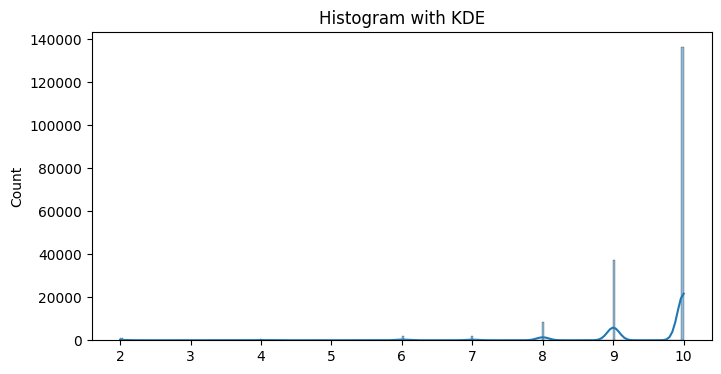

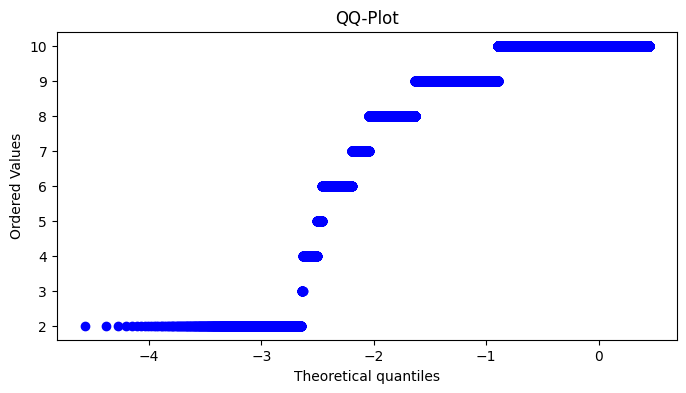

In [31]:
# Calculate normal distribution (tinh phan phoi chuan)
# https://www.datacamp.com/tutorial/normality-test

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Tính các chỉ số
# Dữ liệu chuẩn thường có:
# Mean approx Median (Trung bình gan bang Trung vị)
# Skewness approx 0 (Độ lệch)
# Kurtosis approx 0 (Độ nhọn - theo định nghĩa Fisher)
# Nếu |Skewness| > 1 hoặc |Kurtosis| > 1
# dữ liệu có khả năng lệch nhiều so với phân phối chuẩn
stats_df = df_listing.select([
    pl.col("review_scores_accuracy").mean().alias("mean"),
    pl.col("review_scores_accuracy").median().alias("median"),
    pl.col("review_scores_accuracy").skew().alias("skewness"),
    pl.col("review_scores_accuracy").kurtosis(fisher=True).alias("kurtosis")
])
print(stats_df)

# 1.1 Histogram: Kiểm tra xem dữ liệu có hình chuông không.
plt.figure(figsize=(8,4))
sns.histplot(df_listing["review_scores_accuracy"], kde=True)
plt.title("Histogram with KDE")
plt.show()

# 1.2 QQ-Plot: : Kiểm tra xem các điểm dữ liệu có nằm trên đường thẳng chéo không
plt.figure(figsize=(8,4))
stats.probplot(df_listing["review_scores_accuracy"], dist="norm", plot=plt)
plt.title("QQ-Plot")
plt.show()


In [32]:
# Kiểm định Shapiro-Wilk (Statistical Test)
# Đây là phương pháp phổ biến để kiểm tra phân phối chuẩn
# H0 (Null Hypothesis): Dữ liệu tuân theo phân phối chuẩn.
# H1 (Alternative Hypothesis): Dữ liệu không tuân theo phân phối chuẩn.
# Nếu p-value > 0.05: Không đủ cơ sở bác bỏ H0 -> Dữ liệu có thể là phân phối chuẩn.
# Nếu p-value <= 0.05: Bác bỏ H0 -> Dữ liệu không phải phân phối chuẩn.

from scipy.stats import shapiro

df_listing_pandas = df_listing.to_pandas()
data = df_listing_pandas["review_scores_accuracy"].dropna().to_numpy()
stat, p = shapiro(data) # For N > 5000, computed p-value may not be accurate

print(f"Shapiro-Wilk Test: Statistics={stat:.3f}, p-value={p:.3f}")

if p > 0.05:
    print("Dữ liệu có vẻ là phân phối chuẩn (không đủ cơ sở bác bỏ H0)")
else:
    print("Dữ liệu không tuân theo phân phối chuẩn (bác bỏ H0)")

stat, p_value = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
print(f"Kolmogorov-Smirnov test: {stat:.4f}, p-value: {p_value:.4f}")

stat, p_value = stats.normaltest(data)
print(f"D'Agostino-Pearson test: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk Test: Statistics=0.476, p-value=0.000
Dữ liệu không tuân theo phân phối chuẩn (bác bỏ H0)
Kolmogorov-Smirnov test: 0.3950, p-value: 0.0000
D'Agostino-Pearson test: 163783.7451, p-value: 0.0000


/home/user/dapractice/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 187999.
  res = hypotest_fun_out(*samples, **kwds)


<Axes: >

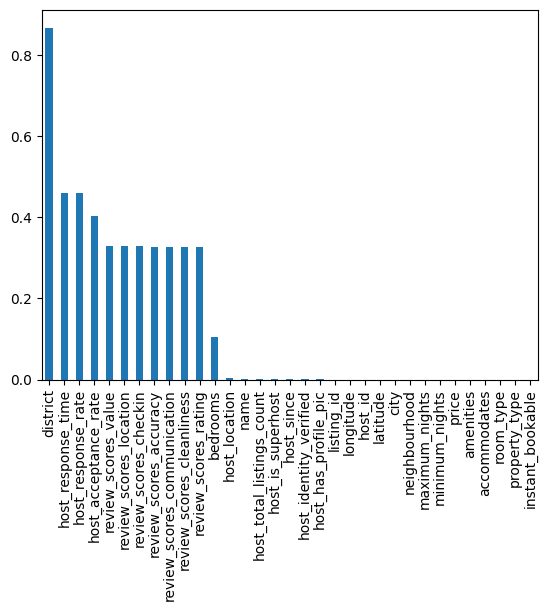

In [33]:
df_listing_pandas.isnull().mean().sort_values(ascending=False).plot.bar()

<Axes: >

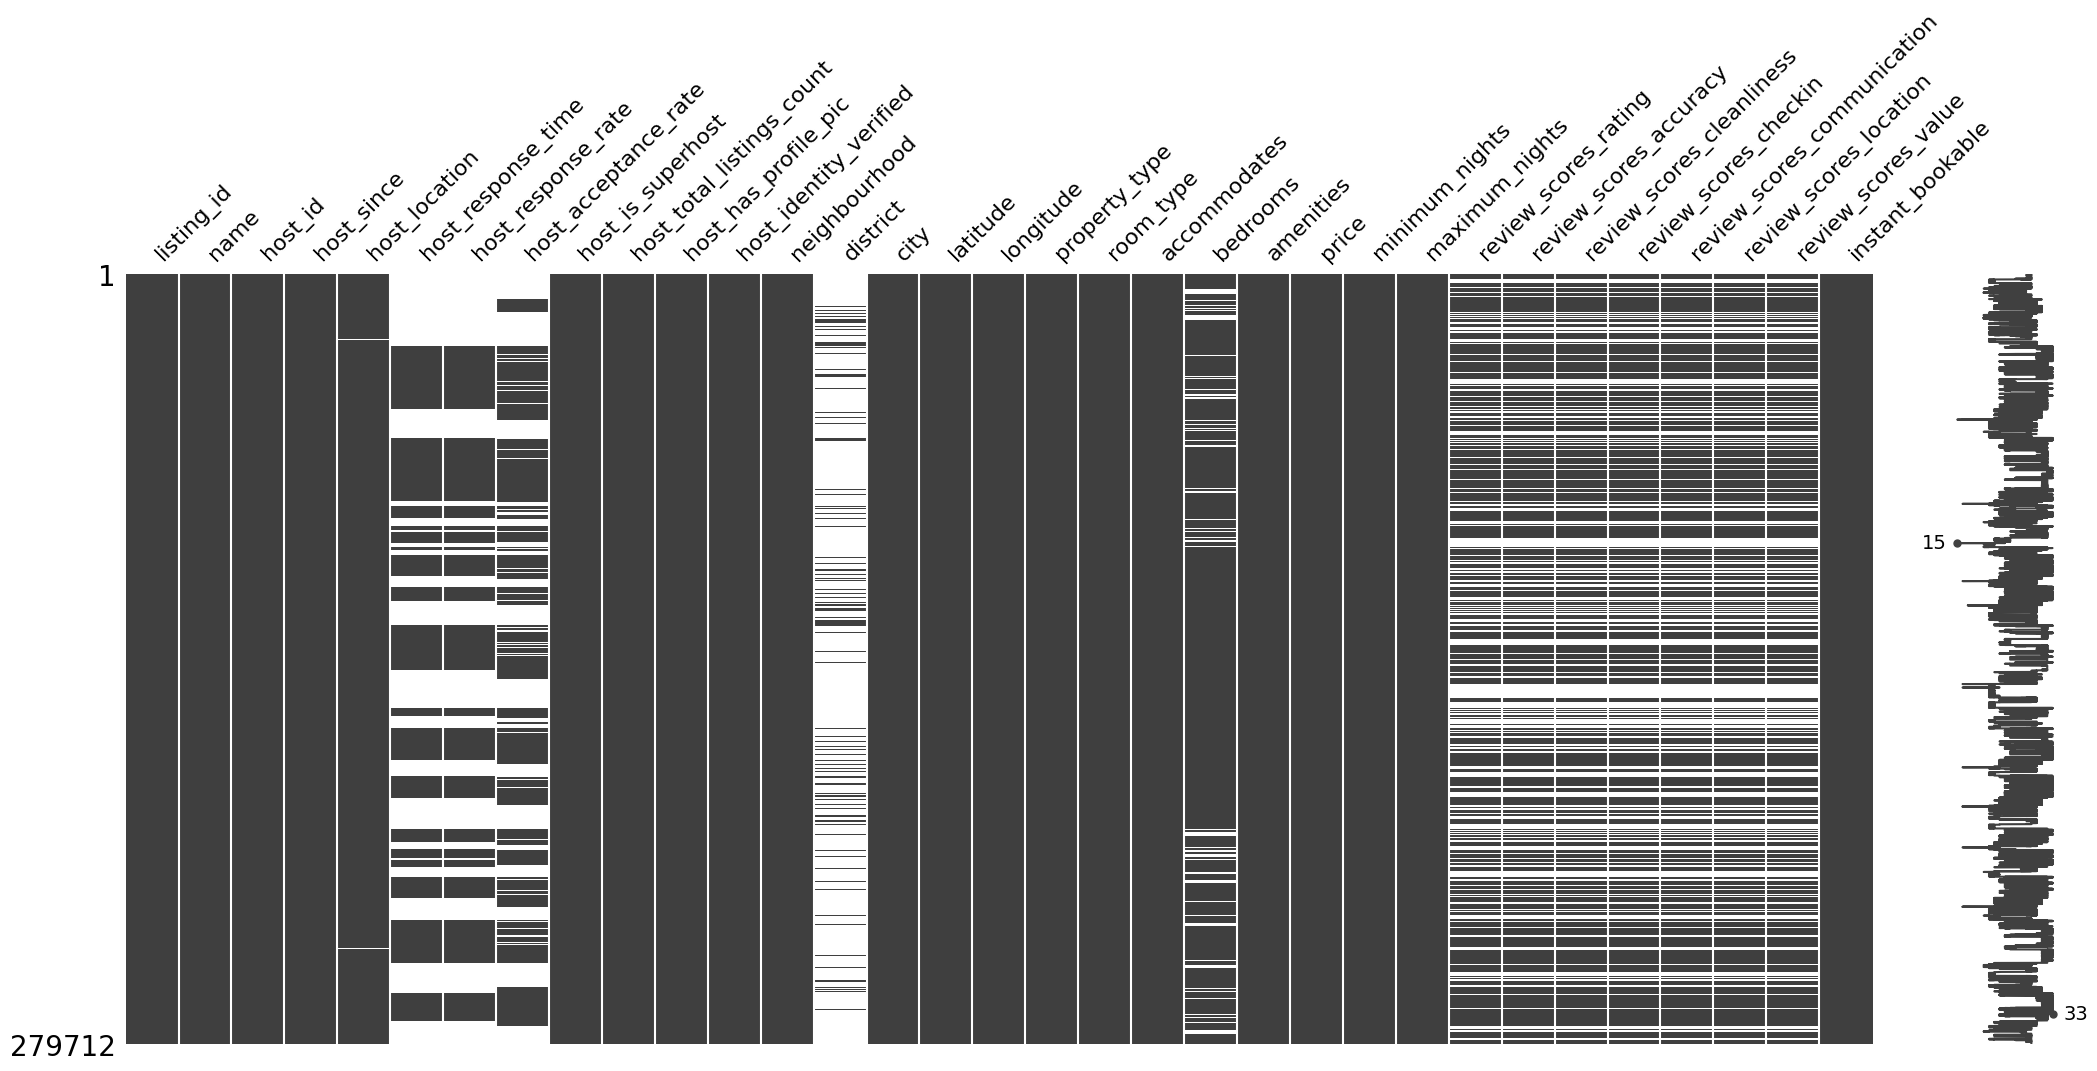

In [34]:
import missingno as msno
msno.matrix(df_listing.to_pandas())

<Axes: >

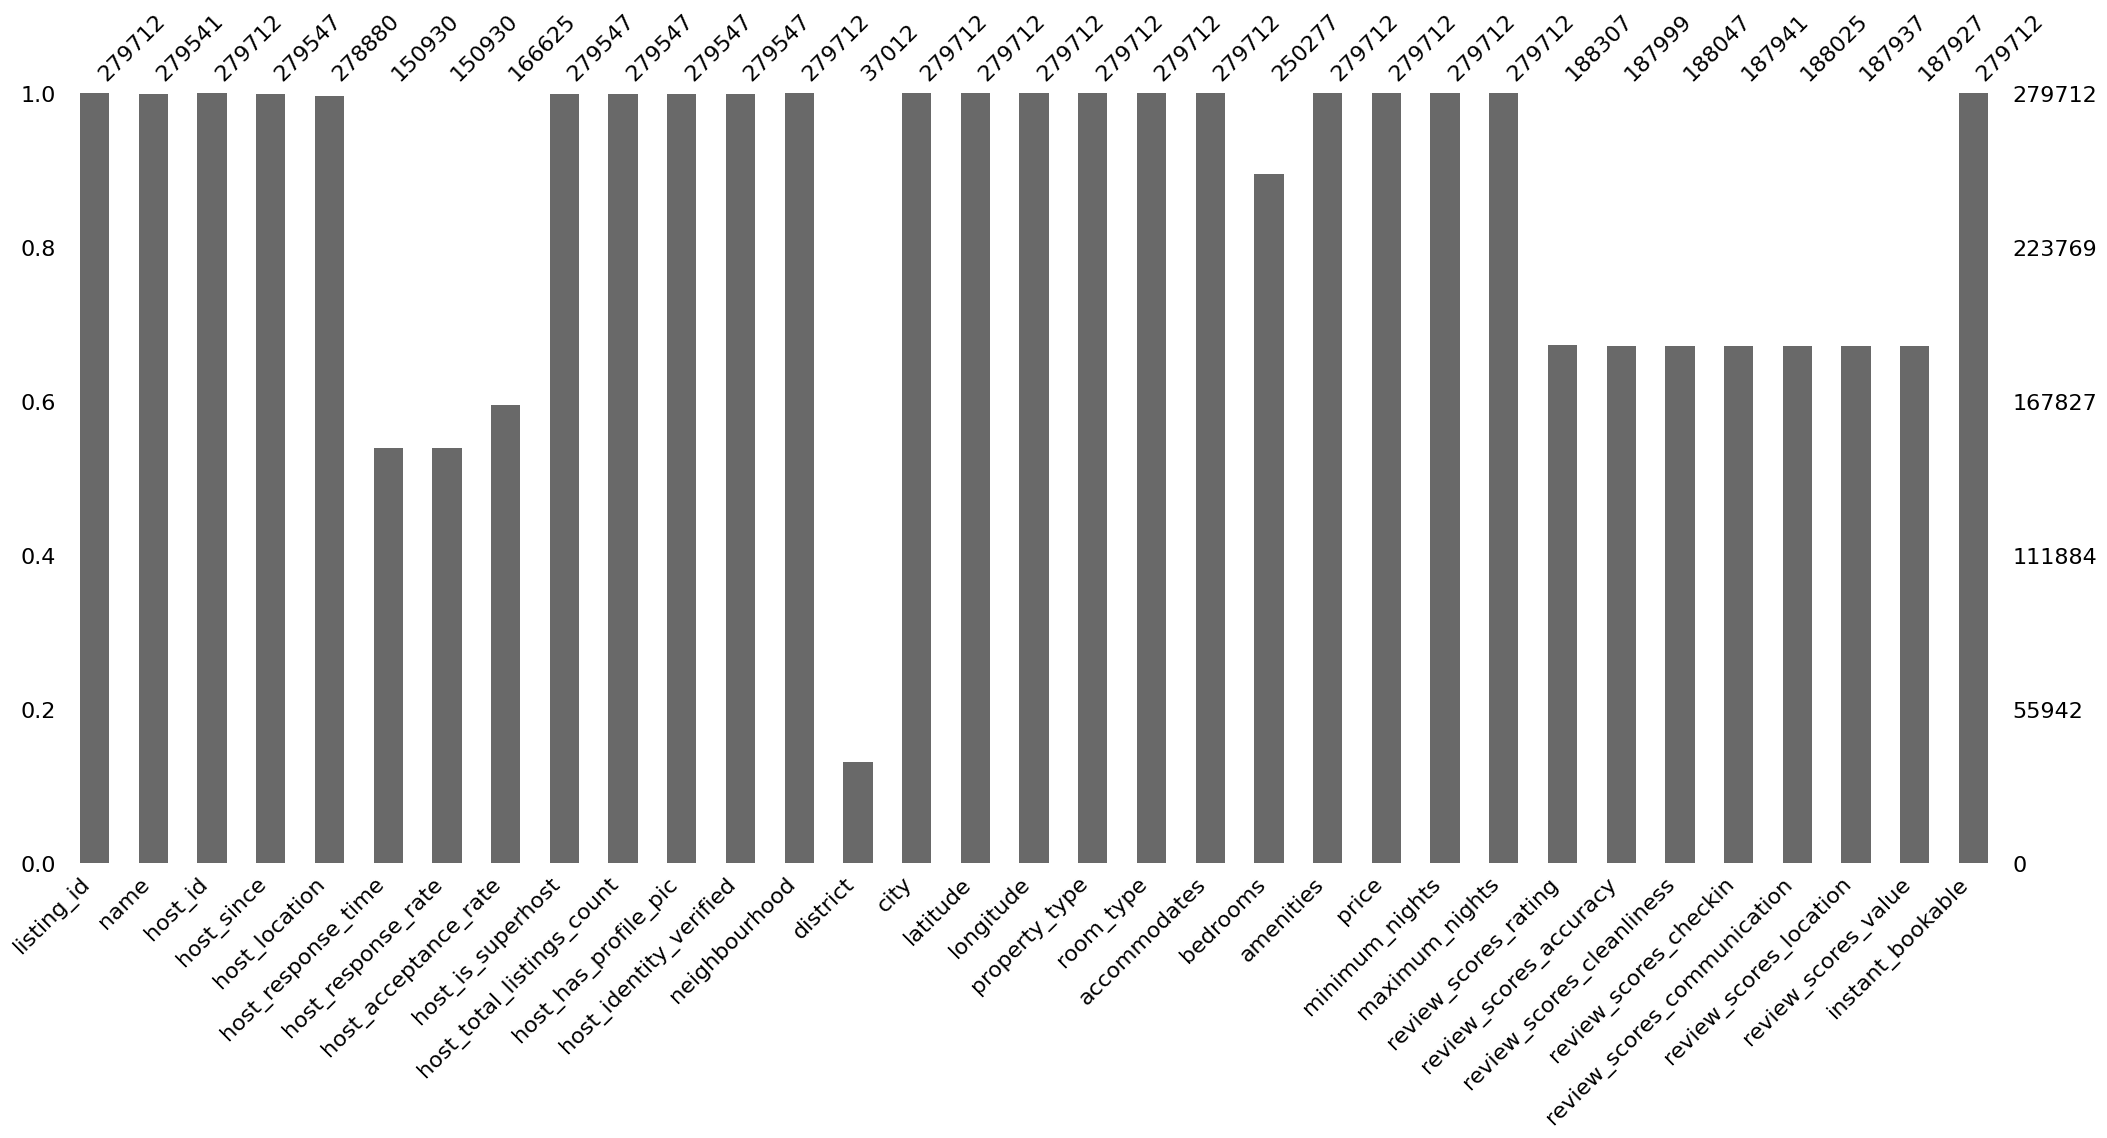

In [35]:
msno.bar(df_listing.to_pandas())

<Axes: >

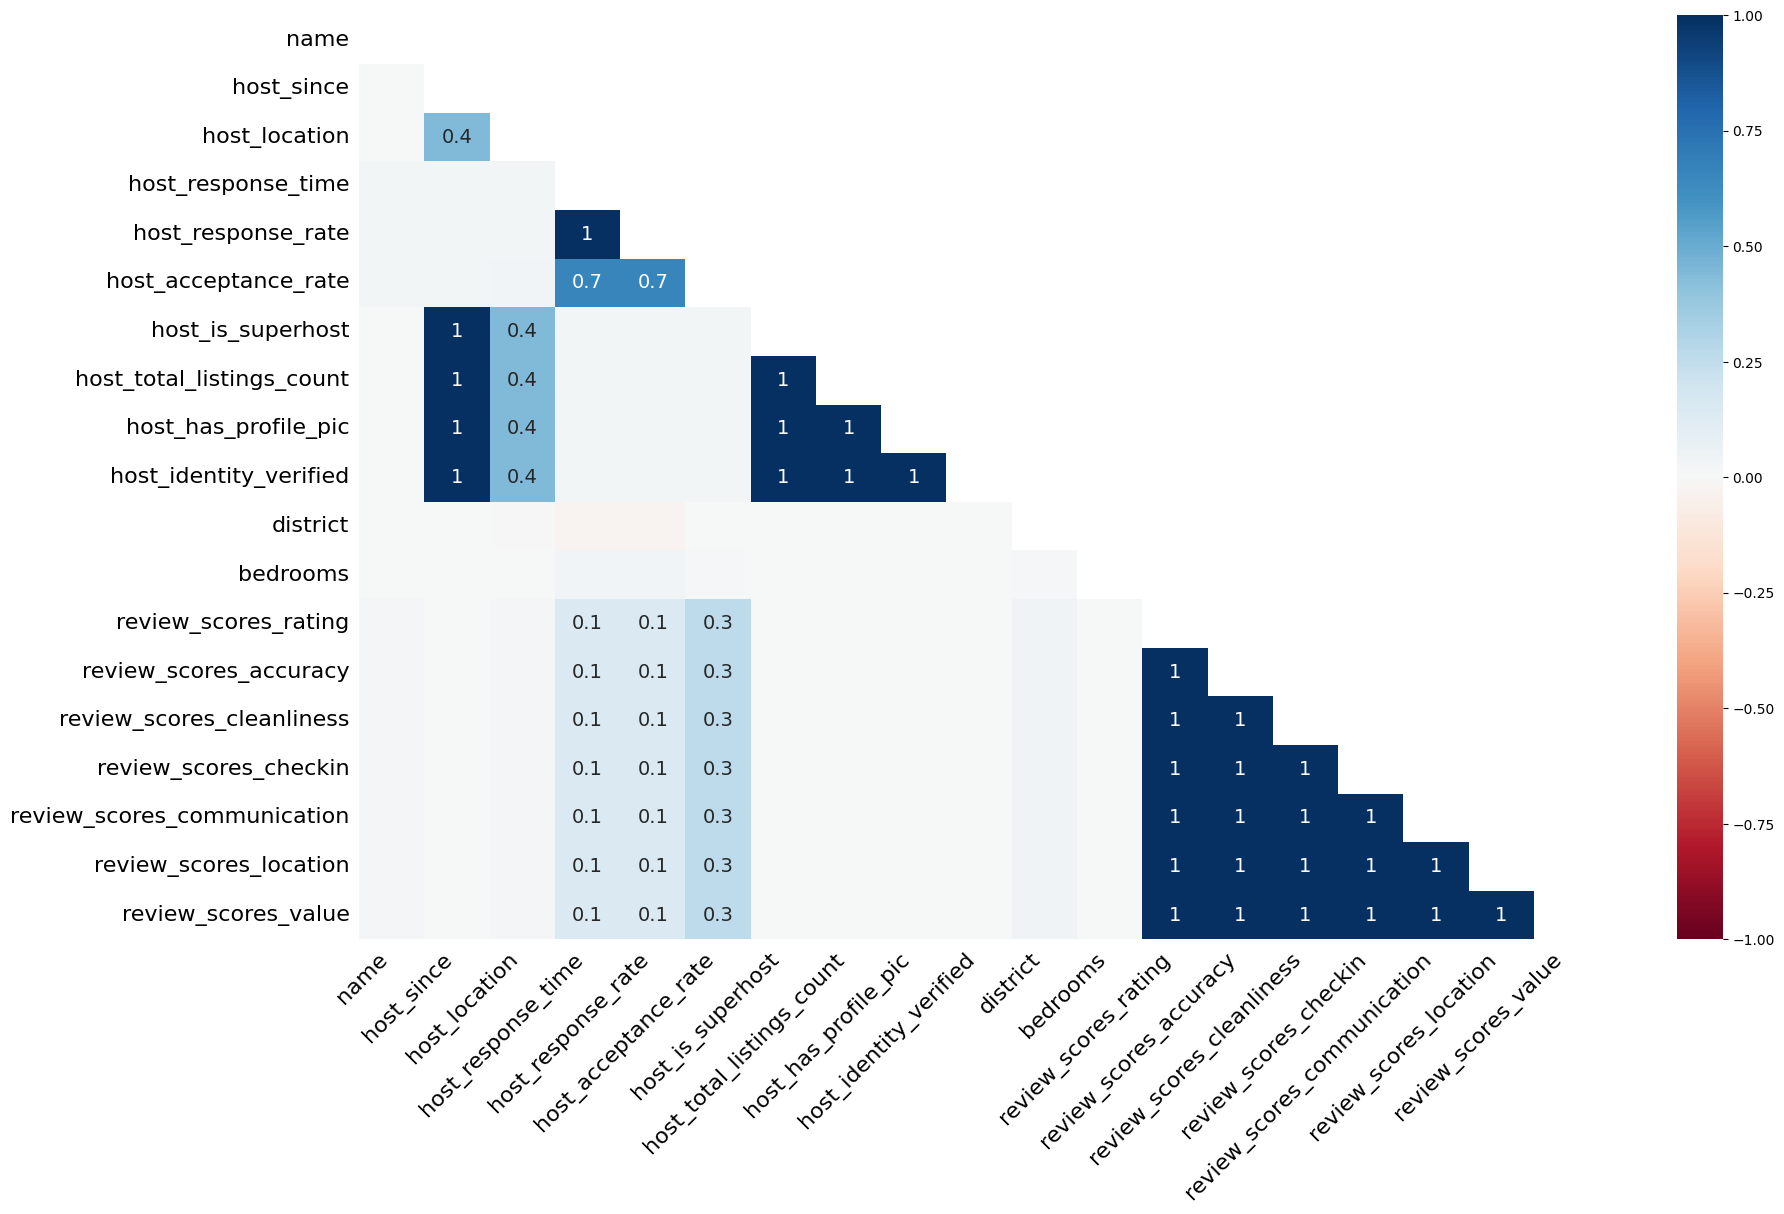

In [36]:
"""
The values range from -1 to 1.
1.0 (Dark Blue): Perfect Correlation. If Column A is missing, Column B is always missing.
Look at your chart: host_is_superhost and host_since have a 1. This confirms they are tied together at the source. If the scraper or API fails to get the host's basic info, it loses everything related to that host.

0.0 (Gray/Blank): No Correlation. Missing values in Column A tell you nothing about missing values in Column B.
Example: name has almost no correlation with anything else.

-1.0 (Dark Red): Inverse Correlation (Rare). If Column A is missing, Column B is never missing.

< 1.0 (e.g., 0.4 or 0.7): Strong but not perfect.
Example: host_response_time and host_acceptance_rate have a 0.7. This means they usually go missing together, but not always.

Weak correlation (0.1 - 0.3):
review_scores_* ↔ host_response_rate/time/acceptance_rate: Hosts who respond well get slightly better reviews — logical but not strongly predictive

Features with NO correlation (blank rows/cols): name, host_since, district, bedrooms — either categorical or weakly related to everything else, may need encoding or further investigation
"""
msno.heatmap(df_listing.to_pandas()) # Values near +1 = maybe missing together (MNAR)

<Axes: >

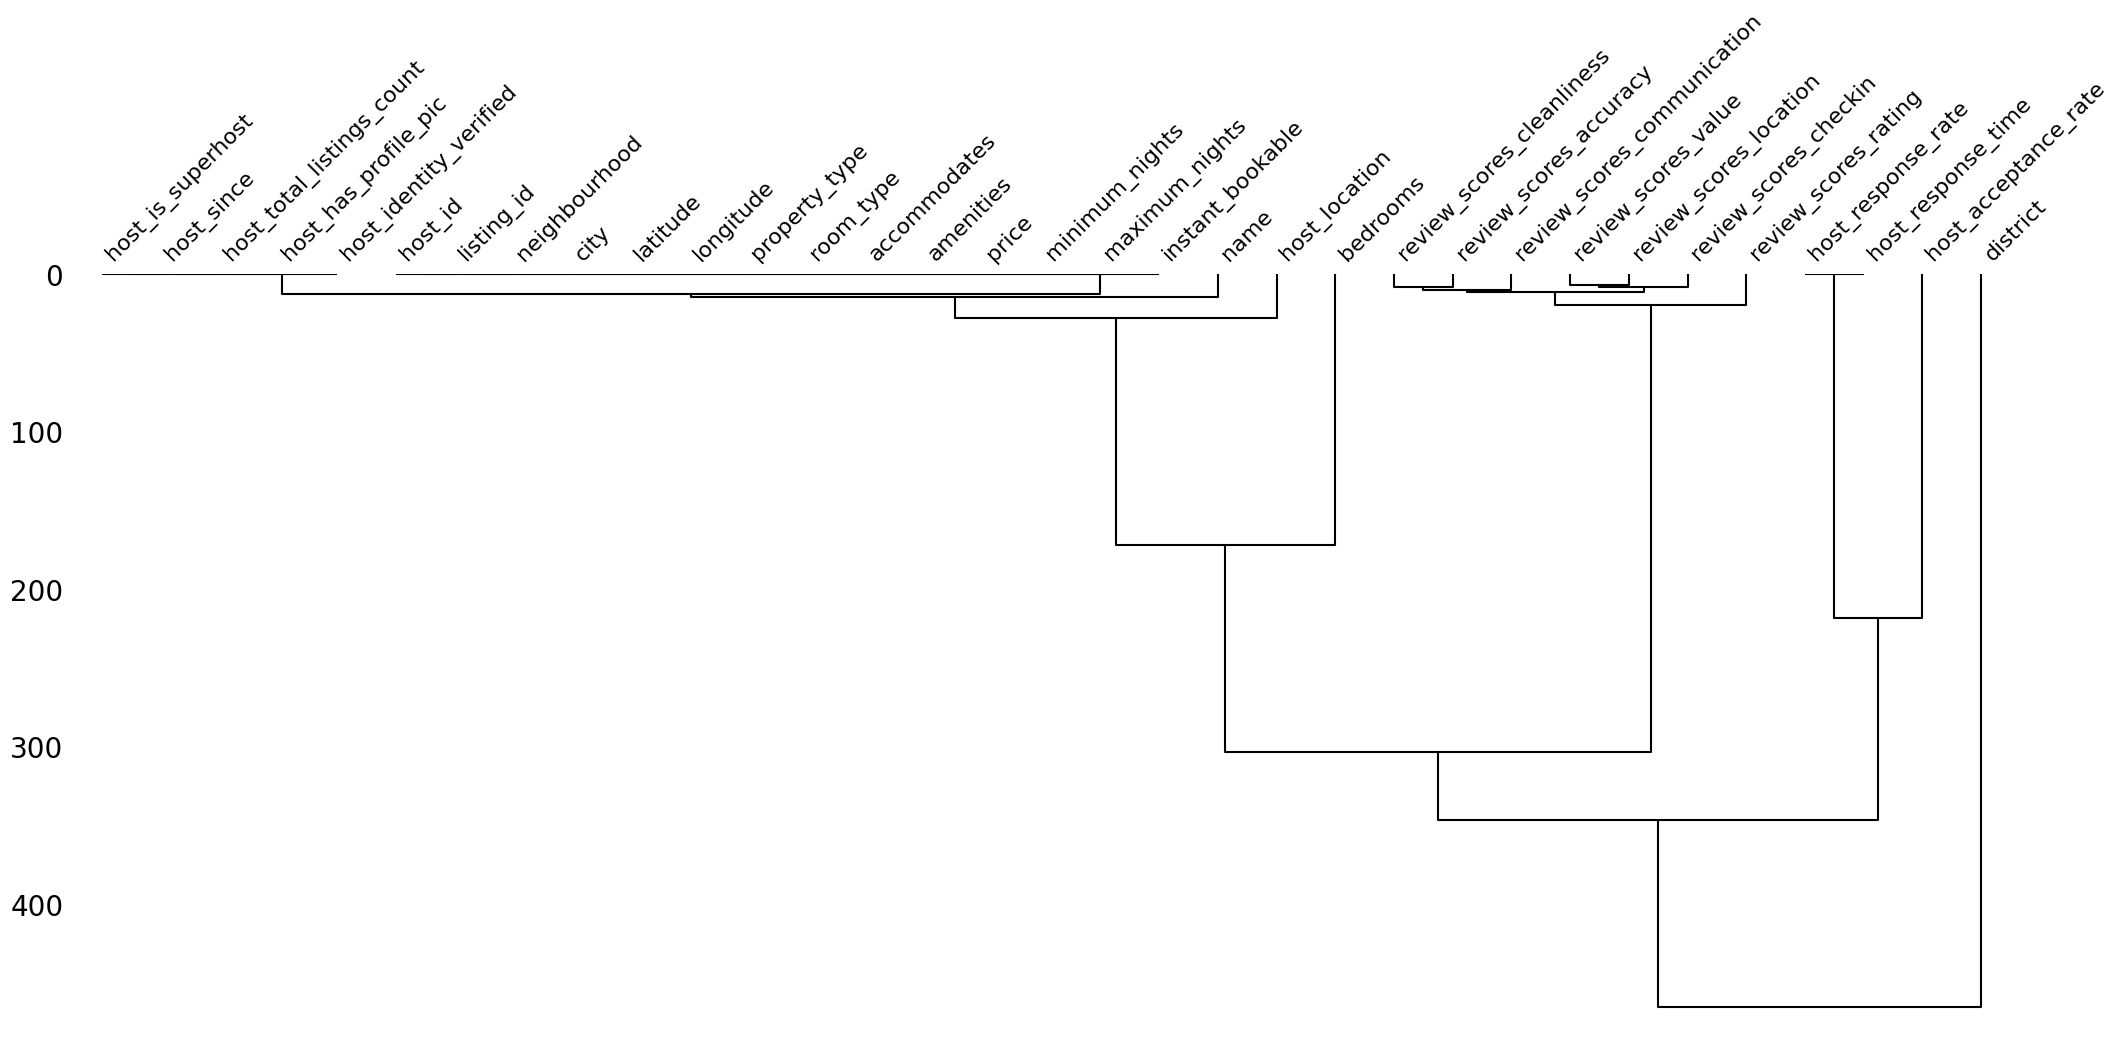

In [37]:
# display relationship between missing values and target variable
"""
1. The Horizontal Distance (Closeness) -> su tuong quan giua cac bien, cang gan 0 thi cac bien cang co su tuong quan lon
Columns that are connected by very short lines at the top are highly correlated.
Example: Look at host_is_superhost, host_since, and host_total_listings_count. They are all joined at the very top (near 0). This means that whenever one is missing, the others are almost certainly missing too.
SDET Insight: This suggests these fields come from the same source "Host Profile" object. If one fails to migrate, they all fail.

2. The Vertical Clusters (The Branches)
The deeper the "V" or "U" shape goes before connecting, the less correlated the missing data is.
The Right-Side Cluster: Notice review_scores_rating, review_scores_accuracy, etc., are grouped together. This makes sense: if a listing has no reviews, all the sub-scores will be null.
The Outliers: Columns like district or host_acceptance_rate connect much further down (near 300-400). This means their missingness is independent of the other groups.
"""
msno.dendrogram(df_listing.to_pandas()) # Tight cluster = same rows -> can be missing together

<Axes: >

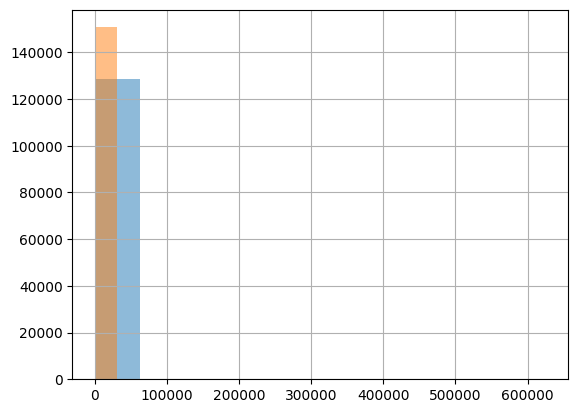

In [38]:
# Compare distributions of other columns when column X is present vs. missing. Difference = MAR or MNAR evidence.
mask = df_listing_pandas['host_response_rate'].isna()
df_listing_pandas[mask]['price'].hist(alpha=0.5,label='when missing')
df_listing_pandas[~mask]['price'].hist(alpha=0.5,label='when present')

In [39]:
# Statistical test. p-value > 0.05 = MCAR (safe to drop/simple impute). p < 0.05 = not MCAR, need careful strategy.

from pyampute.exploration.mcar_statistical_tests import MCARTest
import numpy as np

mcar = MCARTest(method="little")

result = mcar.little_mcar_test(df_listing_pandas.select_dtypes(include=[np.number]))

print(result) # < 0.05 -> likely MAR or MNAR else MCAR


0.0


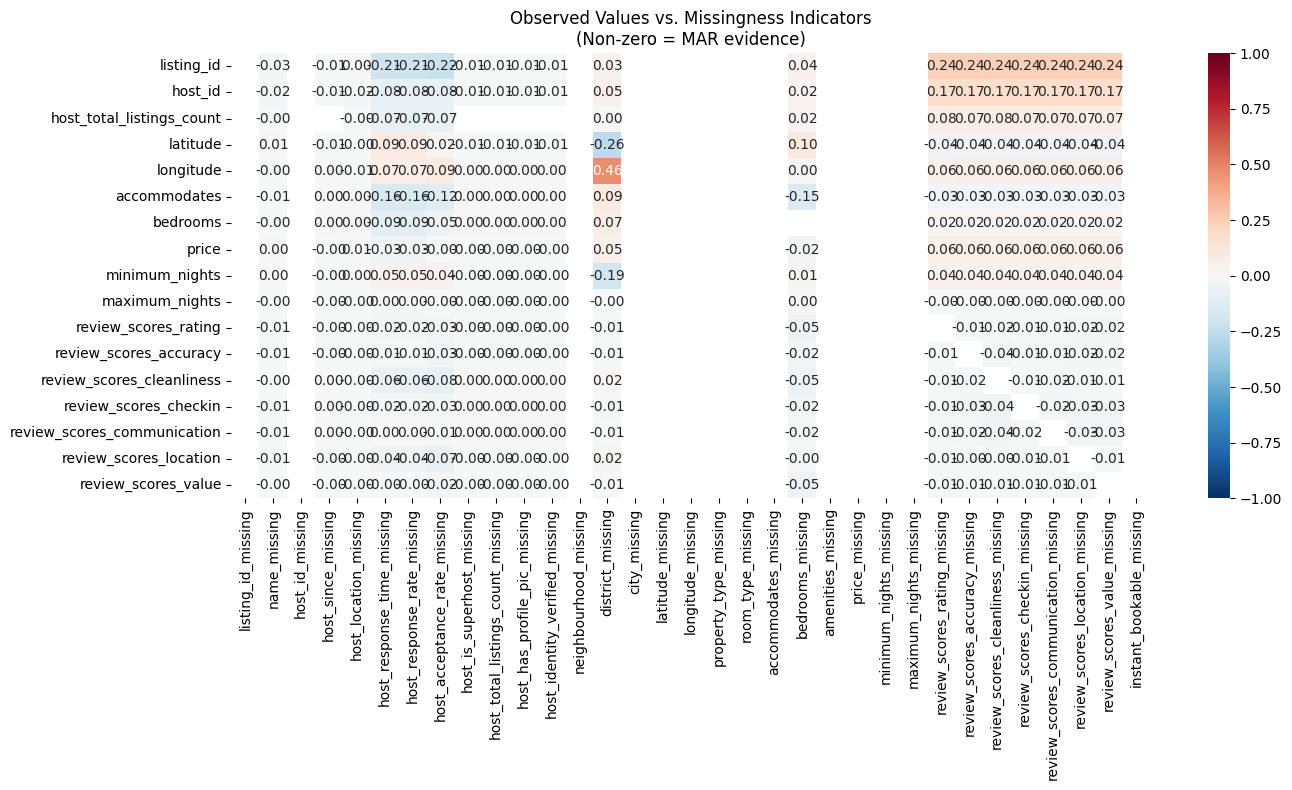

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create missingness indicators
missing_indicators = df_listing_pandas.isnull().astype(int)
missing_indicators = missing_indicators.add_suffix('_missing')

# Correlate missingness flags with observed numeric data
numeric_df = df_listing_pandas.select_dtypes(include=[np.number])
correlation_data = pd.concat([numeric_df, missing_indicators], axis=1)

# Compute correlation between observed values and missingness flags
mar_test_corr = correlation_data.corr()
missing_cols = [c for c in mar_test_corr.columns if '_missing' in c]
observed_cols = [c for c in mar_test_corr.columns if '_missing' not in c]

# Plot: Are observed values predictive of missingness?
plt.figure(figsize=(14, 8))
sns.heatmap(
    mar_test_corr.loc[observed_cols, missing_cols],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f'
)
plt.title('Observed Values vs. Missingness Indicators\n(Non-zero = MAR evidence)')
plt.tight_layout()

In [41]:
# from little_mcar_test import mcar_test

# stat, p_value, df = mcar_test(df_listing_pandas)
# print(f"Little's MCAR test: χ²={stat:.2f}, p={p_value:.4f}, df={df}")

# if p_value < 0.05:
#     print("REJECT MCAR → Missingness is NOT random. Use MAR/MNAR methods.")
# else:
#     print("Fail to reject MCAR → Simple methods may be acceptable.")

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

col = 'review_scores_rating'
data = df_listing_pandas[[col]].copy()

methods = {
    'Original (observed only)': data.dropna(),
    'Mean imputation': SimpleImputer(strategy='mean').fit_transform(data),
    'Median imputation': SimpleImputer(strategy='median').fit_transform(data),
    'KNN (k=5)': KNNImputer(n_neighbors=5).fit_transform(data),
    'MICE': IterativeImputer(random_state=42, max_iter=10).fit_transform(data)
}
print(methods.to_markdown())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, values) in enumerate(methods.items()):
    ax = axes[idx]
    ax.hist(values, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.2f}')
    ax.set_title(name)
    ax.legend()

plt.suptitle('Distribution Distortion by Imputation Method', fontsize=14)
plt.tight_layout()

In [45]:
# Example: Are review scores missing more for new hosts?
df_listing_pandas['host_tenure_years'] = (pd.to_datetime('today') - pd.to_datetime(df_listing_pandas['host_since'])).dt.days / 365
df_listing_pandas['is_new_host'] = df_listing_pandas['host_tenure_years'] < 1

missing_by_subgroup = df_listing_pandas.groupby('is_new_host').agg({
    'review_scores_rating': lambda x: x.isnull().mean(),
    'review_scores_accuracy': lambda x: x.isnull().mean(),
    'review_scores_cleanliness': lambda x: x.isnull().mean()
})

print(missing_by_subgroup.to_markdown())
# If new hosts have 40% missing reviews vs. 10% for established hosts → MAR

| is_new_host   |   review_scores_rating |   review_scores_accuracy |   review_scores_cleanliness |
|:--------------|-----------------------:|-------------------------:|----------------------------:|
| False         |               0.326783 |                 0.327884 |                    0.327712 |


Fill missing data strategy:
- name: need unique, so fill null by "unknowm_name_" + row index
- host_location: as name
- for binary string as host_has_profile_pic, host_identity_verified, which can imply that can be True/False in realistic,  has missing data, so can apply strategy: "t", "f" and fill null by "na" as not given.
- for other string data like district, if having missing data, can fill "na" as not givent or "unknown" to imply that don't know data/missing.
- if missing data not have statistic meaning or no need pay attention, like district, can ignore or drop

for host_response_time, host_response_rate, ..., fill missing data or just calculate and statistics based on not na values?

for number data, how to deal with missing data without lossing realistic or cause biased (sai lech)
threshold nao de xac dinh fill na strategy:
If < thresold
- drop
If > threshold:
- fill mean/median/ffill/bfill (numeric data, for statistics) or fill default value (example: fill default for name)
- KNN/MICE

### Cast type

- after handle missing null, then cast type to willing data type.


In [ ]:
df_listing = df_listing.with_columns(pl.col("host_response_rate").cast(pl.Float64))

In [ ]:
df_listing = df_listing.with_columns(pl.col("host_acceptance_rate").cast(pl.Float64))

In [ ]:
df_listing = df_listing.with_columns(pl.col("host_total_listings_count").cast(pl.Int64))

In [ ]:
df_listing = df_listing.with_columns(pl.col("accommodates").cast(pl.Int64))

In [ ]:
df_listing = df_listing.with_columns(pl.col("bedrooms").cast(pl.Int64))

In [ ]:
df_listing = df_listing.with_columns(pl.col("minimum_nights").cast(pl.Int64))

In [ ]:
df_listing = df_listing.with_columns(pl.col("maximum_nights").cast(pl.Int64))

### Convert to True/False

In [ ]:
true_false_mapping: dict = {
    "t": True,
    "f": False
}
mapping_col: list = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable"
]
df_listing = df_listing.with_columns([
    pl.col(col).map_elements(
        lambda x: true_false_mapping.get(x, None),
        return_dtype=pl.Boolean
    ).alias(col)
    for col in mapping_col
])
df_listing.head()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
f64,str,f64,str,str,str,f64,f64,bool,i64,bool,bool,str,str,str,f64,f64,str,str,i64,i64,str,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,bool
281420.0,"""Beautiful Flat in le Village M…",1.466919e6,"""2011-12-03""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,false,"""Buttes-Montmartre""",null,"""Paris""",48.88668,2.33343,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""Kitchen"", ""Washer…",53.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
3.705183e6,"""39 m² Paris (Sacre Cœur)""",1.0328771e7,"""2013-11-29""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,true,"""Buttes-Montmartre""",null,"""Paris""",48.88617,2.34515,"""Entire apartment""","""Entire place""",2,1,"""[""Shampoo"", ""Heating"", ""Kitche…",120.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
4.082273e6,"""Lovely apartment with Terrace,…",1.9252768e7,"""2014-07-31""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,false,"""Elysee""",null,"""Paris""",48.88112,2.31712,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""TV"", ""Kitchen"", ""…",89.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
4.797344e6,"""Cosy studio (close to Eiffel t…",1.0668311e7,"""2013-12-17""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,true,"""Vaugirard""",null,"""Paris""",48.84571,2.30584,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""TV"", ""Kitchen"", ""…",58.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
4.823489e6,"""Close to Eiffel Tower - Beauti…",2.4837558e7,"""2014-12-14""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,false,"""Passy""",null,"""Paris""",48.855,2.26979,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""TV"", ""Kitchen"", ""…",60.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false


### Categorize data/Enum data

In [ ]:
# unique_property = df_listing["property_type"].fill_null("unknown_property").unique().sort()
# unique_property = pl.Enum(unique_property)
# unique_property

In [ ]:
# df_enum = df_listing.with_columns(pl.col("property_type").cast(unique_property))
# df_enum.head()

In [ ]:
# unique_rooms = df_listing["room_type"].fill_null("unknown_category").unique().sort()
# unique_rooms = pl.Enum(unique_rooms)
# print(unique_rooms)

In [ ]:
# df_enum = df_enum.with_columns(pl.col("room_type").cast(unique_rooms))
# df_enum.head()

In [ ]:
# Watch amenities data and each value amount
import polars as pl

df = df_listing.with_columns(
    pl.col("amenities").str.json_decode(dtype=pl.List(pl.Utf8)).alias("amenities")
)

df_explode = df.explode("amenities")

df_explode = (
    df_explode
    .select(pl.col("amenities").value_counts(sort=True))
    .unnest("amenities")
)

In [ ]:
df_explode.shape

(3447, 2)

In [ ]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_explode)

shape: (3_447, 2)
┌─────────────────────────────────┬────────┐
│ amenities                       ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Wifi                            ┆ 260090 │
│ Essentials                      ┆ 253532 │
│ Long term stays allowed         ┆ 241054 │
│ Kitchen                         ┆ 240923 │
│ TV                              ┆ 213037 │
│ Hangers                         ┆ 211356 │
│ Hair dryer                      ┆ 188724 │
│ Iron                            ┆ 187756 │
│ Washer                          ┆ 185073 │
│ Heating                         ┆ 184327 │
│ Dedicated workspace             ┆ 179267 │
│ Shampoo                         ┆ 174082 │
│ Hot water                       ┆ 165163 │
│ Smoke alarm                     ┆ 156467 │
│ Air conditioning                ┆ 142693 │
│ Dishes and silverware           ┆ 123394 │
│ Refrigerator                    ┆ 1

## Next part

## Tranform data to utf8 for pandas reading

In [ ]:
# ## Check file encoding
# import chardet

# def detect_file_encoding(filename):
#     with open(filename, 'rb') as file:
#         raw_data = file.read()
#         result = chardet.detect(raw_data)
#         return result['encoding']

# ## Usage
# print(detect_file_encoding(listing_file_path))

In [ ]:
# pd.read_csv(listing_file_path, encoding='latin1')

In [ ]:
# import chardet

# def validate_encoding(filename):
#     with open(filename, 'rb') as file:
#         raw_data = file.read()
#         result = chardet.detect(raw_data)

#     return {
#         'detected_encoding': result['encoding'],
#         'confidence': result['confidence']
#     }
# validate_encoding(listing_file_path)

In [ ]:
# import codecs

# def normalize_file_encoding(input_file, output_file, target_encoding='utf-8'):
#     try:
#         with codecs.open(input_file, 'r', encoding='utf-8', errors='replace') as source:
#             content = source.read()

#         with codecs.open(output_file, 'w', encoding=target_encoding) as target:
#             target.write(content)

#         print(f"File converted to {target_encoding}")
#     except Exception as e:
#         print(f"Conversion error: {e}")
# normalize_file_encoding(listing_file_path, "listing_encoded.csv")

In [ ]:
# pd.read_csv("listing_encoded.csv")

In [ ]:
# import codecs

# def transcode_to_utf8(source_path, dest_path):
#     with open(source_path, "rb") as src, open(dest_path, "wb") as dst:
#         reader = codecs.iterdecode(src, "latin-1")
#         for line in reader:
#             dst.write(line.encode("utf-8"))

#     print("Transcoding complete.")

# transcode_to_utf8(listing_file_path, "listing_encoded_2.csv")


In [ ]:
# pd.read_csv("listing_encoded_2.csv", encoding="utf8")

In [ ]:
# def normalize_large_file(input_file, output_file):
#     with open(input_file, 'r', encoding='utf-8', errors='replace') as src:
#         with open(output_file, 'w', encoding='utf-8') as dest:
#             for line in src:  # Read one line at a time (Low RAM)
#                 dest.write(line)
#     print("Normalization complete")

# normalize_large_file(listing_file_path, "listing_encoded_3.csv")

In [ ]:
# pd.read_csv("listing_encoded_3.csv")